In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import sem, t
from utils.colors import C3
from utils.utils import progress_bar
from utils.problem_setup import TestProblemsSetup
from utils.exact_forward_operator import ExactForwardOperator
from algorithms.rsvd_solvers import MatrixFreeRSVD, MatrixFreeRSVDAdjoint

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
PROBLEM = TestProblemsSetup(n=32).get_test_problems()
SEED = 15

In [15]:
def experiment(
        p_list: list,
        pid: str,
        repeat: int = 10,
        k: int = 100
    ) -> pd.DataFrame:
    pb = PROBLEM[pid]

    rsvd = MatrixFreeRSVD(pb['V_h'])
    rsvd_adj = MatrixFreeRSVDAdjoint(pb['V_h'])

    # Compute SVD
    exact = ExactForwardOperator(pb['V_h'])
    _, Sf, _ = np.linalg.svd(exact.K, full_matrices=False)
    Sf = Sf[:k]  # numpy array of size k

    step = 1
    tot_steps = repeat * len(p_list)
    results = []
    for r in range(repeat):
        for p in p_list:
            progress_bar(step, tot_steps)
            step += 1

            _, Sr, _ = rsvd.solve(k=k, p=p, seed=SEED + r + p)
            rsvd_adj.solve(k=k, p=p, seed=SEED + r + p)
            _, SrAdj, _ = rsvd_adj.recover_K()
            ratio = Sr / Sf
            ratio_adj = SrAdj / Sf

            for i, (val, val_adj) in enumerate(zip(ratio, ratio_adj)):
                results.append({'r': r, 'p': p, 'i': i, 'ratio': val, 'ratio_adj': val_adj})

    return pd.DataFrame(results)


In [51]:
setup = TestProblemsSetup(n=32)
problems = setup.get_test_problems()
ratio = {}

p_list = [0, 5, 10]
df = experiment(
    p_list=p_list,
    pid='I',
    repeat=20,
)


[##############################] 60/60


In [52]:
df = df.groupby(['p', 'i']).agg(
    ratio_mean=('ratio', 'mean'),
    ratio_std=('ratio', 'std'),
    ratio_adj_mean=('ratio_adj', 'mean'),
    ratio_adj_std=('ratio_adj', 'std'),
).reset_index()

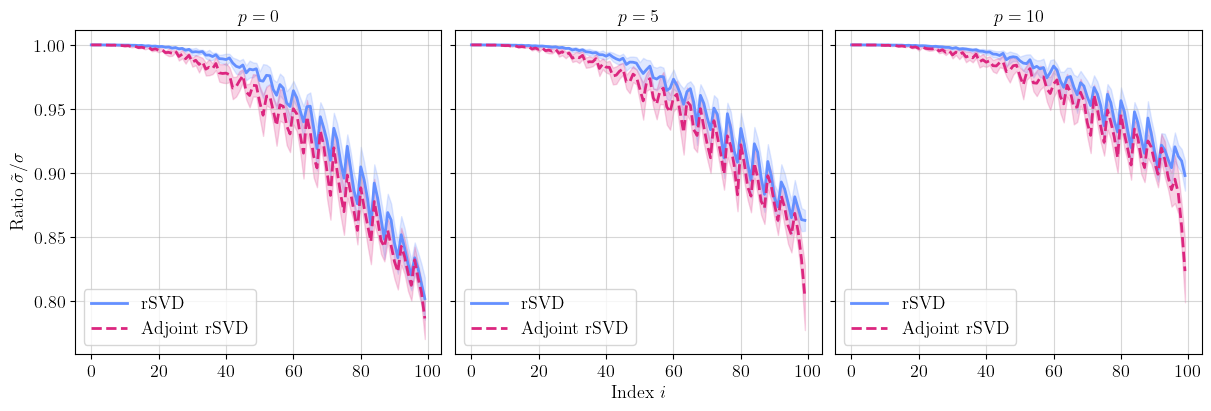

In [97]:
from utils.colors import M, MS, C2
from utils.plotting import save_plot


fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True, sharey=True)

for ax, p in zip(axes.flat, [0, 5, 10]):
    df_sub = df[df.p == p]

    # rSVD mean
    ax.plot(df_sub.i, df_sub['ratio_mean'], c=C2[0], lw=2, ls='-', label='rSVD')
    ax.fill_between(
        df_sub.i,
        df_sub['ratio_mean'] - df_sub['ratio_std'],
        df_sub['ratio_mean'] + df_sub['ratio_std'],
        color=C2[0],
        alpha=0.2
    )

    # Adjoint rSVD mean
    ax.plot(df_sub.i, df_sub['ratio_adj_mean'], c=C2[1], lw=2, ls='--', label='Adjoint rSVD')
    ax.fill_between(
        df_sub.i,
        df_sub['ratio_adj_mean'] - df_sub['ratio_adj_std'],
        df_sub['ratio_adj_mean'] + df_sub['ratio_adj_std'],
        color=C2[1],
        alpha=0.2
    )

    ax.set_title(f'$p={p}$', fontsize=13)
    ax.grid(True, alpha=.5)
    ax.legend()

axes[1].set_xlabel('Index $i$')
axes[0].set_ylabel('Ratio $\\tilde \sigma / \sigma$')
save_plot('rsvd_adjoint_singular_values')
plt.show()